# ДЗ Линейная регрессия

В данном задании мы рассмотрим набор данных об учащихся, собранный в 2006 году в одной из школ Португалии. Данные представлены в неудобном для машинного обучения виде, и содержат мусор. Ваша задача &mdash; привести их к надлежащему виду и обучить на них простую модель.

Данные состоят из четырех файлов:
- data.csv &mdash; основная таблица с информацией о учащихся
- scores.csv &mdash; список финальных оценок по одному из предметов (20-балльная шкала переведенная в проценты)
- attendance.csv &mdash; таблица посещений занятий по этому предмету
- school_support.txt &mdash; список учащихся, которым оказывается финансовая поддержка

Ваша задача &mdash; построить модель для предсказания финальных оценок исходя из всех остальных данных и проверить качество ее работы с помощью кросс-валидации. В качестве алгоритма мы будем использовать линейную регрессию

Расшифровка столбцов в data.csv для справки:
- age &mdash; возраст
- Medu &mdash; уровень образования матери (по некоторой условной шкале)
- Fedu &mdash; уровень образования отца (по некоторой условной шкале)
- traveltime &mdash; время в пути до школы (1 – < 15 мин., 2 – от 15 до 30 мин., 3 – от 30 мин. to 1 ч.
или 4 – > 1 ч.)
- studytime &mdash; время, затрачиваемое на занятия вне школы (1 – < 2 ч., 2 – от 2 до 5 ч., 3 – от 5 до 10 ч. или 4 – > 10 ч.)
- famrel &mdash; насколько хорошие отношения в семье у учащегося (по некоторой условной шкале)
- freetime &mdash; количество свободного времени вне школы (по некоторой условной шкале)
- goout &mdash; время, затрачиваемое на общение с друзьями (по некоторой условной шкале)
- Dalc &mdash; количество употребления алкоголя в учебные дни (по некоторой условной шкале)
- Walc &mdash; количество употребления алкоголя в неучебные дни (по некоторой условной шкале)
- health &mdash; уровень здоровья (по некоторой условной шкале)
- sex_M &mdash; пол: мужской (1) или женский (0)
- address_U &mdash; живет ли учащийся в городе (1) или в пригороде (0)
- famsize_LE3 &mdash; размер семьи: не больше 3 человек (1) или больше (0)
- Pstatus_T &mdash; живут ли родители вместе (1) или отдельно (0)
- nursery &mdash; посещал ли учащийся детский сад
- plans_university &mdash; планирует ли учащийся поступать в университет (-1 или 1)
- past_failures &mdash; количество неудовлетворительных оценок по другим предметам ранее (от 0 до 4)

*Примечание. Несколько признаков в данных содержат ошибки/проблемы/некорректности. Эти проблемы нужно исправить. Для
проверки &mdash; всего в данных таких проблем четыре.*

Начиная с 4 пункта делайте кроссвалидацию на 4 батча до и после, замеряйте результат

### Задача 1: сломанный признак (а может и не один)
__(1 балл)__

Загрузите таблицу data.csv.

Найдите в данных сломанный признак (он не соответствует описанию) и исправьте его.

In [120]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold

data = pd.read_csv('data.csv')

In [121]:
mask = data['age'] > 100
data.loc[mask, 'age'] = 2006 - data.loc[mask, 'age']

data['plans_university'] = data['plans_universitypast_failures'].astype(str).str[:-1].astype(int)
data['past_failures'] = data['plans_universitypast_failures'].astype(str).str[-1].astype(int)

data = data.drop(columns=['plans_universitypast_failures'])

print(data[['age', 'plans_university', 'past_failures']].head())

   age  plans_university  past_failures
0   16                 1              0
1   17                 1              0
2   16                 1              0
3   18                -1              0
4   17                 1              0


### Задача 2: пропуски в данных 
__(1 балл)__

Проверьте, есть ли в данных пропуски (значения NaN). Замените все пропущенные значения на среднее значение этого признака по столбцу.

*Hint: изучите в pandas функции loc, isnull, а также передачу булевых массивов в качестве индексов.*

In [122]:
print("Пропуски до заполнения:")
print(data.isnull().sum())

for col in data.columns:
    mask = data[col].isnull()
    data.loc[mask, col] = int(data[col].mean())

print("\nПропуски после заполнения:")
print(data.isnull().sum())
print('\n')
print(data.head())

Пропуски до заполнения:
age                  0
Medu                 0
Fedu                 0
traveltime           0
studytime            0
famrel               0
freetime             0
goout                1
Dalc                10
Walc                 6
health               0
sex_M                0
address_U            0
famsize_LE3          0
Pstatus_T            0
nursery              0
plans_university     0
past_failures        0
dtype: int64

Пропуски после заполнения:
age                 0
Medu                0
Fedu                0
traveltime          0
studytime           0
famrel              0
freetime            0
goout               0
Dalc                0
Walc                0
health              0
sex_M               0
address_U           0
famsize_LE3         0
Pstatus_T           0
nursery             0
plans_university    0
past_failures       0
dtype: int64


   age  Medu  Fedu  traveltime  studytime  famrel  freetime  goout  Dalc  \
0   16     4     4           1    

### Задача 3: нормализация данных
__(1 балл)__

Нормализуйте данные любым способом, в современных библиотеках нормализация часто встроена внутрь модели, поэтому тут разницы может и не быть в качестве, но сделать надо

In [123]:
from sklearn.preprocessing import MinMaxScaler

feature_columns = data.columns.tolist()

scaler = MinMaxScaler()
data = pd.DataFrame(
    scaler.fit_transform(data),
    columns=feature_columns,
    index=data.index
)

print(data.head())

        age  Medu  Fedu  traveltime  studytime  famrel  freetime  goout  Dalc  \
0  0.142857  1.00  1.00    0.000000   0.333333    1.00      0.75   0.75  0.00   
1  0.285714  1.00  1.00    0.000000   0.000000    1.00      0.50   0.75  0.00   
2  0.142857  0.25  0.25    0.020408   0.000000    0.75      1.00   1.00  0.25   
3  0.428571  0.25  0.50    0.020408   0.000000    0.50      0.75   0.75  0.25   
4  0.285714  0.50  0.25    0.020408   0.333333    0.75      0.25   1.00  0.00   

   Walc  health  sex_M  address_U  famsize_LE3  Pstatus_T  nursery  \
0  0.25    1.00    1.0        1.0          0.0        1.0      1.0   
1  0.25    1.00    0.0        1.0          0.0        1.0      1.0   
2  0.75    1.00    1.0        0.0          1.0        1.0      1.0   
3  0.75    0.75    1.0        1.0          0.0        1.0      0.0   
4  0.25    1.00    0.0        0.0          0.0        1.0      1.0   

   plans_university  past_failures  
0               1.0            0.0  
1               1.

### Задача 4: кросс-валидация для исходных данных
__(1 балл)__

Загрузите файл scores.csv и протестируйте, как линейная регрессия предсказывает ответ сейчас (с помощью кросс-валидации).

Кроссвалидацию сделайте по 4 разбивкам. Выведите качество в каждом их разбиений.

*Hint: воспользуйтесь sklearn.linear_model и sklearn.model_selection.*

In [124]:
scores = pd.read_csv('scores.csv', header=None, names=['score'])

In [125]:
x = data.values
y = scores['score'].values

model = LinearRegression()

kf = KFold(n_splits=4, shuffle=True, random_state=2169756215)

scores_r2 = cross_val_score(model, x, y, cv=kf, scoring='r2')

print("\nR² на каждом фолде:")
for i, s in enumerate(scores_r2, 1):
    print(f"  Фолд {i}: {s:.4f}")

print(f"\nСредний R²: {scores_r2.mean():.4f}")
print(f"Стандартное отклонение: {scores_r2.std():.4f}")


R² на каждом фолде:
  Фолд 1: 0.2496
  Фолд 2: 0.0670
  Фолд 3: 0.2609
  Фолд 4: 0.2512

Средний R²: 0.2072
Стандартное отклонение: 0.0810


### Задача 5: полные данные
__(2 балла)__

Воспользуйтесь файлами attendance.csv и school_support.txt для того, чтобы добавить новые признаки в данные. Желательно по максимуму использовать возможности pandas для упрощения преобразований.

school_suport число в строке значит что i-ый школьник из исходной таблицы получал мат помощь (обратите внимание что строк в файле меньше, подумайте как правильно импортировать данные)

Добавьте данные таким образом, чтобы качество выросло

In [126]:
with open('school_support.txt') as f:
    supported_ids = [int(line.strip()) for line in f if line.strip()]

data['school_support'] = data.index.isin([sid - 1 for sid in supported_ids]).astype(int)

attendance = pd.read_csv('attendance.csv', sep=';')

attendance_bin = (attendance == '+').astype(int)

data['attendance_count'] = attendance_bin.sum(axis=1).values

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data[['attendance_count', 'school_support']] = scaler.fit_transform(
    data[['attendance_count', 'school_support']]
)

print(data.head())

        age  Medu  Fedu  traveltime  studytime  famrel  freetime  goout  Dalc  \
0  0.142857  1.00  1.00    0.000000   0.333333    1.00      0.75   0.75  0.00   
1  0.285714  1.00  1.00    0.000000   0.000000    1.00      0.50   0.75  0.00   
2  0.142857  0.25  0.25    0.020408   0.000000    0.75      1.00   1.00  0.25   
3  0.428571  0.25  0.50    0.020408   0.000000    0.50      0.75   0.75  0.25   
4  0.285714  0.50  0.25    0.020408   0.333333    0.75      0.25   1.00  0.00   

   Walc  health  sex_M  address_U  famsize_LE3  Pstatus_T  nursery  \
0  0.25    1.00    1.0        1.0          0.0        1.0      1.0   
1  0.25    1.00    0.0        1.0          0.0        1.0      1.0   
2  0.75    1.00    1.0        0.0          1.0        1.0      1.0   
3  0.75    0.75    1.0        1.0          0.0        1.0      0.0   
4  0.25    1.00    0.0        0.0          0.0        1.0      1.0   

   plans_university  past_failures  school_support  attendance_count  
0               1.0  

In [127]:
x = data.values
y = scores['score'].values

model = LinearRegression()

kf = KFold(n_splits=4, shuffle=True, random_state=2169756215)

scores_r2 = cross_val_score(model, x, y, cv=kf, scoring='r2')

print("\nR² на каждом фолде:")
for i, s in enumerate(scores_r2, 1):
    print(f"  Фолд {i}: {s:.4f}")

print(f"\nСредний R²: {scores_r2.mean():.4f}")
print(f"Стандартное отклонение: {scores_r2.std():.4f}")


R² на каждом фолде:
  Фолд 1: 0.2272
  Фолд 2: 0.0625
  Фолд 3: 0.2391
  Фолд 4: 0.2451

Средний R²: 0.1935
Стандартное отклонение: 0.0759


### Задача 6: борьба с выбросами
__(1.5 балла)__

Качество предсказания может ухудшаться, если в данных присутствуют корректные значения признаков (с точки зрения чтения данных и применения методов), но не соответствующие реальным объектам. Например, данные могли быть введены в неверном формате, а потом слишком грубо приведены к общему виду, из-за чего ошибка не была замечена.
Попробуем от такого избавиться &mdash; а для этого такие объекты нужно сначала найти. Конечно, нам еще недоступны многие продвинутые способы, но давайте попробуем обойтись простыми.

Первый способ это сделать &mdash; посмотреть для каждого признака на распределение его значений и проверить крайние значения на правдоподобность. (постройте гистограммы для признаков, как минимум для подозрительных)

*Hint 1: используйте функцию DataFrame.hist*

*Hint 2: в описании датасета выше есть информация, необходимая для восстановления правильных значений*

__(1.5 балла)__

Другой простой способ найти выбросы &mdash; сделать предсказание и посчитать ошибку на каждом объекте по отдельности и посмотреть на объекты с наибольшей ошибкой. Обучите линейную регрессию (функция fit) и для каждого объекта посчитайте среднеквадратичное отклонение. Постройте гистограмму распределения ошибок. Посмотрите на гистограмму и удалите из выборки те объекты на которых ошибка слишком большая.

Обратите внимание, что просто удалять все объекты с высокой ошибкой нельзя &mdash; это, конечно, хороший способ добиться меньшей ошибки (на данной выборке), но одновременно вы ухудшите обобщающую способность алгоритма. Вместо этого вам нужно найти однозначно ошибочные записи и их исправить.

*Hint: возможно, все проблемы уже были найдены первым способом; для проверки &mdash; в сумме здесь нужно исправить 3 проблемы.*

Для поиска ошибки на одном отдельном обьекте придётся обучить линейную регрессию руками. Частичный пример, допишите код. Постройте гистограмму распределения ошибок

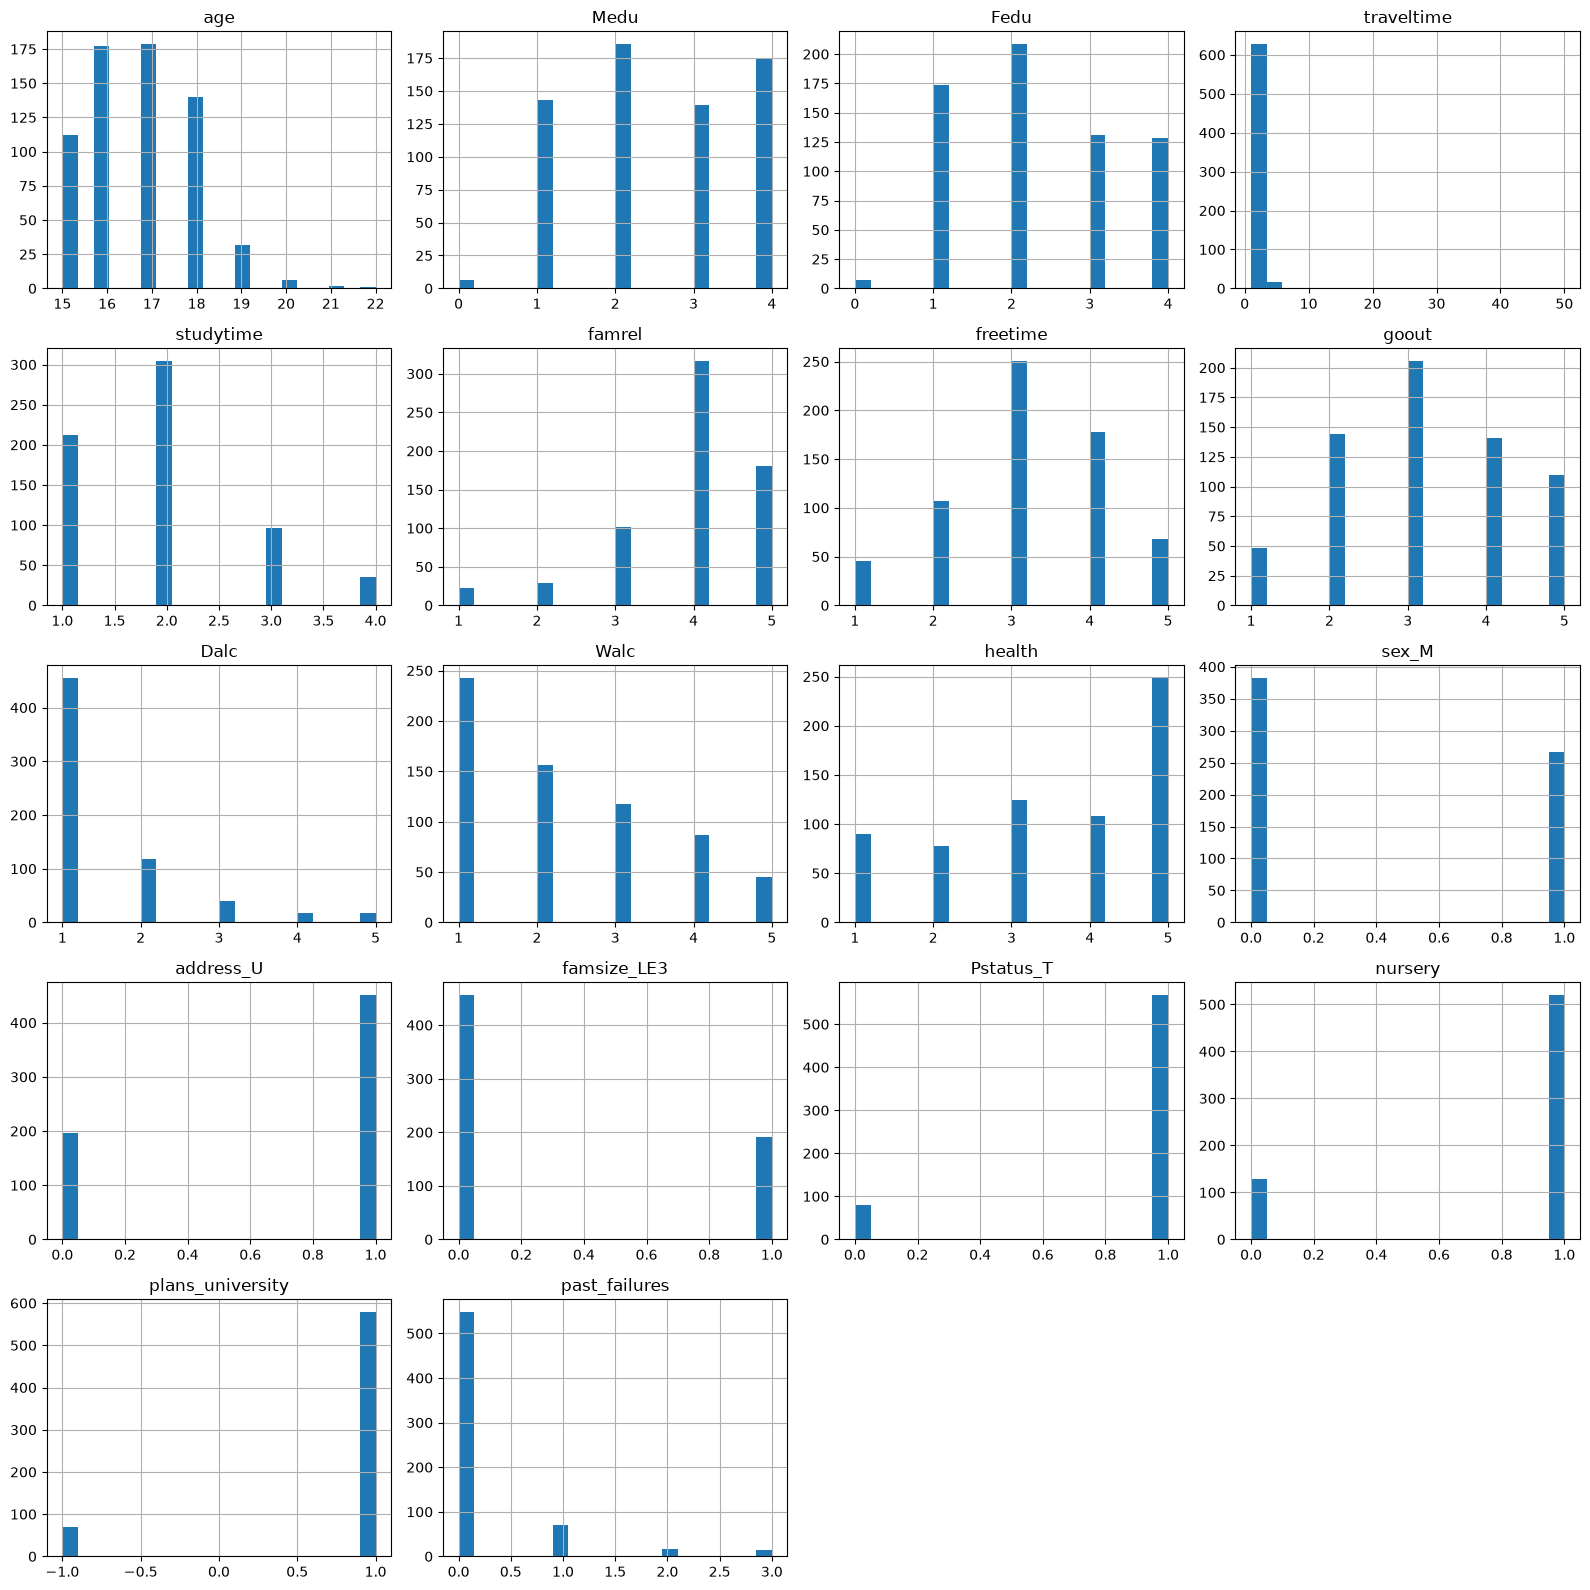


Уникальные score до: [np.float64(0.0), np.float64(0.35), np.float64(0.5), np.float64(0.55), np.float64(0.7), np.float64(5.0), np.float64(25.0), np.float64(30.0), np.float64(35.0), np.float64(40.0), np.float64(45.0), np.float64(50.0), np.float64(55.0), np.float64(60.0), np.float64(65.0), np.float64(70.0), np.float64(75.0), np.float64(80.0), np.float64(85.0), np.float64(90.0), np.float64(95.0)]

Уникальные score после: [np.float64(25.0), np.float64(30.0), np.float64(35.0), np.float64(40.0), np.float64(45.0), np.float64(50.0), np.float64(55.0), np.float64(60.0), np.float64(65.0), np.float64(70.0), np.float64(75.0), np.float64(80.0), np.float64(85.0), np.float64(90.0), np.float64(95.0)]


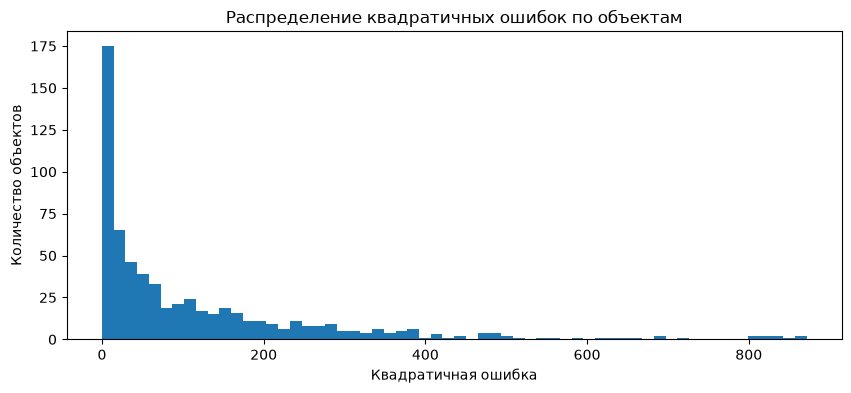

Топ-10 объектов с наибольшей ошибкой:
  index=164  score=  70.0  prediction= 69.52  error=  871.40
  index=187  score=  60.0  prediction= 60.48  error=  871.38
  index=429  score=  50.0  prediction= 60.84  error=  850.15
  index=531  score=  65.0  prediction= 61.05  error=  838.04
  index= 16  score=  90.0  prediction= 61.20  error=  829.19
  index=553  score=  65.0  prediction= 58.71  error=  824.20
  index=136  score=  80.0  prediction= 51.29  error=  824.08
  index=118  score=  40.0  prediction= 68.47  error=  810.43
  index= 80  score=  35.0  prediction= 63.29  error=  800.44
  index=261  score=  75.0  prediction= 53.28  error=  714.03


In [128]:
df = pd.read_csv('data.csv')
scores = pd.read_csv('scores.csv', header=None, names=['score'])
attendance = pd.read_csv('attendance.csv', sep=';')

mask = df['age'] > 100
df.loc[mask, 'age'] = 2006 - df.loc[mask, 'age']

df['plans_university'] = df['plans_universitypast_failures'].astype(str).str[:-1].astype(int)
df['past_failures'] = df['plans_universitypast_failures'].astype(str).str[-1].astype(int)
df = df.drop(columns=['plans_universitypast_failures'])

for col in df.columns:
    mask = df[col].isnull()
    df.loc[mask, col] = int(df[col].mean())

df.hist(figsize=(16, 16), bins=20)
plt.tight_layout()
plt.show()

traveltime_fix = {10: 1, 25: 2, 40: 3, 50: 4}
df['traveltime'] = df['traveltime'].replace(traveltime_fix)

print("\nУникальные score до:", sorted(scores['score'].unique()))

score_fix = {0.35: 35.0, 0.5: 50.0, 0.55: 55.0, 0.7: 70.0, 5.0: 50.0}
scores['score'] = scores['score'].replace(score_fix)

mask_zero = scores['score'] == 0.0
df = df.loc[~mask_zero].reset_index(drop=True)
scores = scores.loc[~mask_zero].reset_index(drop=True)
attendance = attendance.loc[~mask_zero].reset_index(drop=True)

print("\nУникальные score после:", sorted(scores['score'].unique()))

with open('school_support.txt') as f:
    supported_ids = [int(line.strip()) for line in f if line.strip()]
df['school_support'] = df.index.isin([sid - 1 for sid in supported_ids]).astype(int)

attendance_bin = (attendance == '+').astype(int)
df['attendance_count'] = attendance_bin.sum(axis=1).values

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns,
    index=df.index
)

plt.figure(figsize=(10, 4))
plt.hist(errors, bins=60)
plt.title('Распределение квадратичных ошибок по объектам')
plt.xlabel('Квадратичная ошибка')
plt.ylabel('Количество объектов')
plt.show()

print("Топ-10 объектов с наибольшей ошибкой:")
for idx in np.argsort(errors)[-10:][::-1]:
    print(f"  index={idx:3d}  score={y[idx]:6.1f}  prediction={predictions[idx]:6.2f}  error={errors[idx]:8.2f}")

In [129]:
X = df_scaled.values
y = scores['score'].values

model = LinearRegression()
model.fit(X, y)
predictions = model.predict(X)
errors = (predictions - y) ** 2

kf = KFold(n_splits=4, shuffle=True, random_state=2169756215)
scores_r2 = cross_val_score(model, X, y, cv=kf, scoring='r2')

print("\nR² на каждом фолде:")
for i, s in enumerate(scores_r2, 1):
    print(f"  Фолд {i}: {s:.4f}")

print(f"\nСредний R²: {scores_r2.mean():.4f}")
print(f"Стандартное отклонение: {scores_r2.std():.4f}")


R² на каждом фолде:
  Фолд 1: 0.2644
  Фолд 2: 0.2783
  Фолд 3: 0.1470
  Фолд 4: 0.3132

Средний R²: 0.2507
Стандартное отклонение: 0.0624


### Финальное предсказание и отчёт (1 балл)

Проведите предсказание еще раз и сравните качество с исходным. Запишите свои наблюдения - как изменялось качество обучения модели при использовании разных модификаций данных. 